# Tourism Analysis - Brazil (1989)
In this notebook, I will explore for the first time how to use notebooks.

This will give me experience, not only about notebooks, but about how the dataset I'm working on is composed, so further I can gather the data up to the year of 2024 and make a more profound analysis.

### Main goals for this session:
- Learn how Jupyter notebook works
- Understand the data structure of the Brazilian Open Data Portal (https://dados.gov.br/).
- Practice basic cleaning and aswell Pandas, Seaborn, Matplot and numpy libs.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
travels_df = pd.read_csv('../data/raw/chegadas_1989.csv', encoding='latin1', sep=';')

In [3]:
travels_df.head()

,Continente,Ordem continente,País,Ordem país,UF,Ordem UF,Via de acesso,Ordem via de acesso,ano,Mês,Ordem mês,Chegadas
0,África,1,África do Sul,2,Amazonas,4,Aérea,1,1989,janeiro,1,9.0
1,África,1,Angola,6,Amazonas,4,Aérea,1,1989,janeiro,1,0.0
2,África,1,Nigéria,162,Amazonas,4,Aérea,1,1989,janeiro,1,0.0
3,África,1,Outros países,998,Amazonas,4,Aérea,1,1989,janeiro,1,0.0
4,América Central e Caribe,2,Costa Rica,53,Amazonas,4,Aérea,1,1989,janeiro,1,6.0


In [4]:
travels_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17052 entries, 0 to 17051
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Continente           17052 non-null  str    
 1   Ordem continente     17052 non-null  int64  
 2   País                 17052 non-null  str    
 3   Ordem país           17052 non-null  int64  
 4   UF                   17052 non-null  str    
 5   Ordem UF             17052 non-null  int64  
 6   Via de acesso        17052 non-null  str    
 7   Ordem via de acesso  17052 non-null  int64  
 8   ano                  17052 non-null  int64  
 9   Mês                  17052 non-null  str    
 10  Ordem mês            17052 non-null  int64  
 11  Chegadas             16464 non-null  float64
dtypes: float64(1), int64(6), str(5)
memory usage: 2.3 MB


- travels_df.info() allows me to check in a quick look all my data, I have 17052 lines, a total of 12 columns
- It's interesting to see that I have for most of columns all of the data, we can check that on the non-null count column
we have the same amount of lines as non-null count, means no data is missing for them, but for "Chegadas" we have 16464 non null
which means 588 null lines. We need to check why later.
travels_df[travels_df['Chegadas'].isnull()]

In [5]:
# Removing some of the columns I won't be using, so I can reduce the amount of data, and increase visibility.
cols_remover = ['Ordem continente', 'Ordem país', 'Ordem UF', 'Ordem via de acesso']
travels_df = travels_df.drop(columns=cols_remover)

In [6]:
travels_df.head()

,Continente,País,UF,Via de acesso,ano,Mês,Ordem mês,Chegadas
0,África,África do Sul,Amazonas,Aérea,1989,janeiro,1,9.0
1,África,Angola,Amazonas,Aérea,1989,janeiro,1,0.0
2,África,Nigéria,Amazonas,Aérea,1989,janeiro,1,0.0
3,África,Outros países,Amazonas,Aérea,1989,janeiro,1,0.0
4,América Central e Caribe,Costa Rica,Amazonas,Aérea,1989,janeiro,1,6.0


In [7]:
# Isolate the data where 'Chegadas' == null, to figure out what's going on
null_df = travels_df[travels_df['Chegadas'].isnull()]

In [8]:
null_df.head()

,Continente,País,UF,Via de acesso,ano,Mês,Ordem mês,Chegadas
16464,África,África do Sul,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16465,África,Angola,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16466,África,Nigéria,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16467,África,Outros países,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16468,América Central e Caribe,Costa Rica,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN


In [9]:
# First 5 camps shows the same 'UF', 'Via de acesso', and 'Mês'. Are all null values associated to them?
null_df['UF'].value_counts()

UF
Mato Grosso do Sul    588
Name: count, dtype: int64

In [10]:
null_df['Via de acesso'].value_counts()

Via de acesso
Fluvial    588
Name: count, dtype: int64

In [11]:
null_df['Mês'].value_counts()

Mês
janeiro      49
fevereiro    49
março        49
abril        49
maio         49
junho        49
julho        49
agosto       49
setembro     49
outubro      49
novembro     49
dezembro     49
Name: count, dtype: int64

In [12]:
# In conclusion it seems 'Mato Grosso do Sul' had some kind of problem registering travel records when it was fluvial.
# Next step is trying to figure out why every month has count == 49

null_itens = null_df[null_df['Mês'] == 'janeiro']['País'].unique()
null_itens

<ArrowStringArray>
[           'África do Sul',                   'Angola',
                  'Nigéria',            'Outros países',
               'Costa Rica',                   'Panamá',
               'Porto Rico',                   'Canadá',
           'Estados Unidos',                   'México',
                'Argentina',                  'Bolívia',
                    'Chile',                 'Colômbia',
                  'Equador',          'Guiana Francesa',
                   'Guiana',                 'Paraguai',
                     'Peru',                 'Suriname',
                  'Uruguai',                'Venezuela',
                    'China',      'República da Coreia',
                    'Japão',                 'Alemanha',
                  'Áustria',                  'Bélgica',
                'Dinamarca',                  'Espanha',
                   'França',                   'Grécia',
                  'Holanda',              'Reino Unido',
            

In [13]:
# Ok, so 45 different countries, but it shows 49 every month.

null_january = null_df[null_df['Mês'] == 'janeiro']
null_january.shape

(49, 8)

In [14]:
null_january

,Continente,País,UF,Via de acesso,ano,Mês,Ordem mês,Chegadas
16464,África,África do Sul,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16465,África,Angola,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16466,África,Nigéria,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16467,África,Outros países,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16468,América Central e Caribe,Costa Rica,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16469,América Central e Caribe,Panamá,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16470,América Central e Caribe,Porto Rico,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16471,América Central e Caribe,Outros países,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16472,América do Norte,Canadá,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN
16473,América do Norte,Estados Unidos,Mato Grosso do Sul,Fluvial,1989,janeiro,1,NaN


In [15]:
# Now it's clear what is causing the confusion about the data, 'Outros países' repeats once for all continents except Oceania.

# Handling Missing Values
# Based on our analysis, the 588 null values are restricted to 'Fluvial' access in 'Mato Grosso do Sul'.
# Filling these null values with 0, assuming no arrivals were recorded.
travels_df['Chegadas'] = travels_df['Chegadas'].fillna(0)

In [16]:
# Checking if it worked
travels_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17052 entries, 0 to 17051
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Continente     17052 non-null  str    
 1   País           17052 non-null  str    
 2   UF             17052 non-null  str    
 3   Via de acesso  17052 non-null  str    
 4   ano            17052 non-null  int64  
 5   Mês            17052 non-null  str    
 6   Ordem mês      17052 non-null  int64  
 7   Chegadas       17052 non-null  float64
dtypes: float64(1), int64(2), str(5)
memory usage: 1.8 MB


In [17]:
# Once there are no more null values,'Chegadas' data type doesn't need to be float anymore, converting it to integer (you can't have half a person)
travels_df['Chegadas'] = travels_df['Chegadas'].astype(int)

In [18]:
# Trimming whitespace from all string columns to avoid grouping errors

string_columns = ['Continente', 'País', 'UF', 'Via de acesso', 'Mês']
for col in string_columns:
    travels_df[col] = travels_df[col].str.strip()

In [19]:
# Checking the results
print("Final Data Types:")
print(travels_df.dtypes)

Final Data Types:
Continente         str
País               str
UF                 str
Via de acesso      str
ano              int64
Mês                str
Ordem mês        int64
Chegadas         int64
dtype: object


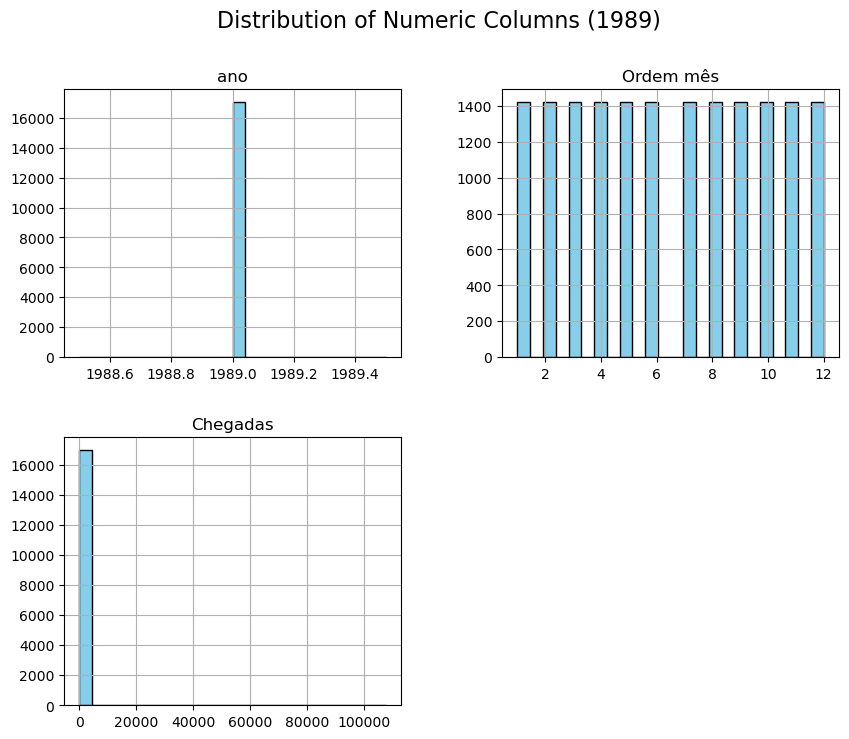

In [20]:
travels_df.hist(figsize=(10, 8), bins=24, color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Numeric Columns (1989)", fontsize=16)
plt.show()

Maybe a Histogram wasn't the best choice here, but exploring is always worth it! 
So even here it's possible to notice how data behaves on these charts

1. Ano: 
Since the dataset is from 1989, only that year should appear but there can also be 'stray' years or typos in the records. 
However, with 16k+ entries, a single wrong year might be invisible in the bars. the code below is to double-check just to be safe:

In [21]:
travels_df['ano'].unique()

array([1989])

2. Ordem mês: 
The second graph confirms that the records are perfectly balanced. Every month has the exact same number of entries, meaning the data structure 
is very consistent across countries and transport types.

3. Chegadas: 
This one is a bit messy and needs some work. Most of the 'Chegadas' values are very close to zero, which causes this huge concentration on the 
left side. It seems we have a few 'giants' (outliers) pushing the scale all the way to 100k making the rest of the data look like a flat line.

In [22]:
# Checking who is responsible for that 100k peak!
travels_df.sort_values(by='Chegadas', ascending=False).head(10)

,Continente,País,UF,Via de acesso,ano,Mês,Ordem mês,Chegadas
10007,América do Sul,Argentina,Rio Grande do Sul,Terrestre,1989,janeiro,1,107476
10056,América do Sul,Argentina,Rio Grande do Sul,Terrestre,1989,fevereiro,2,63628
10115,América do Sul,Uruguai,Rio Grande do Sul,Terrestre,1989,março,3,24182
6479,América do Sul,Argentina,Paraná,Terrestre,1989,janeiro,1,20416
10017,América do Sul,Uruguai,Rio Grande do Sul,Terrestre,1989,janeiro,1,19516
10105,América do Sul,Argentina,Rio Grande do Sul,Terrestre,1989,março,3,18463
10595,América do Sul,Argentina,Rio Grande do Sul,Fluvial,1989,janeiro,1,16198
10066,América do Sul,Uruguai,Rio Grande do Sul,Terrestre,1989,fevereiro,2,15788
10546,América do Sul,Argentina,Rio Grande do Sul,Terrestre,1989,dezembro,12,15293
6486,América do Sul,Paraguai,Paraná,Terrestre,1989,janeiro,1,14537


Conclusion, from data and context we can assume those things

Border Dominance: Countries sharing borders with Brazil dominate the Top 10 list. The South region, in particular, shows the highest volume of arrivals.

Seasonality: January and February mark the peak of the South American summer. The data clearly reflects the impact of summer vacations on tourist flow.

Geopolitical Context: The late 1980s were a turning point for Brazil-Argentina relations, marked by several integration agreements (like the precursor to Mercosul). This political proximity is reflected in the massive number of Argentine tourists.

In [23]:
# Aggregating arrivals by country. 
# Switching from histograms to a categorical approach to better visualize the dominance of top-performing countries.

country_totals = travels_df.groupby('País')['Chegadas'].sum().sort_values(ascending=False).reset_index()
country_totals.head(10)

,País,Chegadas
0,Argentina,449544
1,Uruguai,146252
2,Estados Unidos,146194
3,Paraguai,83928
4,Alemanha,69485
5,Itália,58446
6,Espanha,46684
7,França,45052
8,Bolívia,36898
9,Outros países,28475


In [24]:
# Grouping by both 'Continent' and 'País' to differentiate 'Outros países', because its an aglomerate of countries from many continents

country_totals = travels_df.groupby(['Continente', 'País'])['Chegadas'].sum().sort_values(ascending=False).reset_index()
country_totals.head(10)

,Continente,País,Chegadas
0,América do Sul,Argentina,449544
1,América do Sul,Uruguai,146252
2,América do Norte,Estados Unidos,146194
3,América do Sul,Paraguai,83928
4,Europa,Alemanha,69485
5,Europa,Itália,58446
6,Europa,Espanha,46684
7,Europa,França,45052
8,América do Sul,Bolívia,36898
9,Europa,Suíça,28322


# Historical Contextualization
South American Integration: The dominance of Argentina and Uruguay reflects the beginning of a closer geopolitical era in the Southern Cone.

US Influence: Solidified as the main non-border tourism partner due to business and cultural promotion.

Germany's Lead in Europe: Likely driven by strong cultural ties with Southern Brazil and the high purchasing power of the German Mark in 1989.

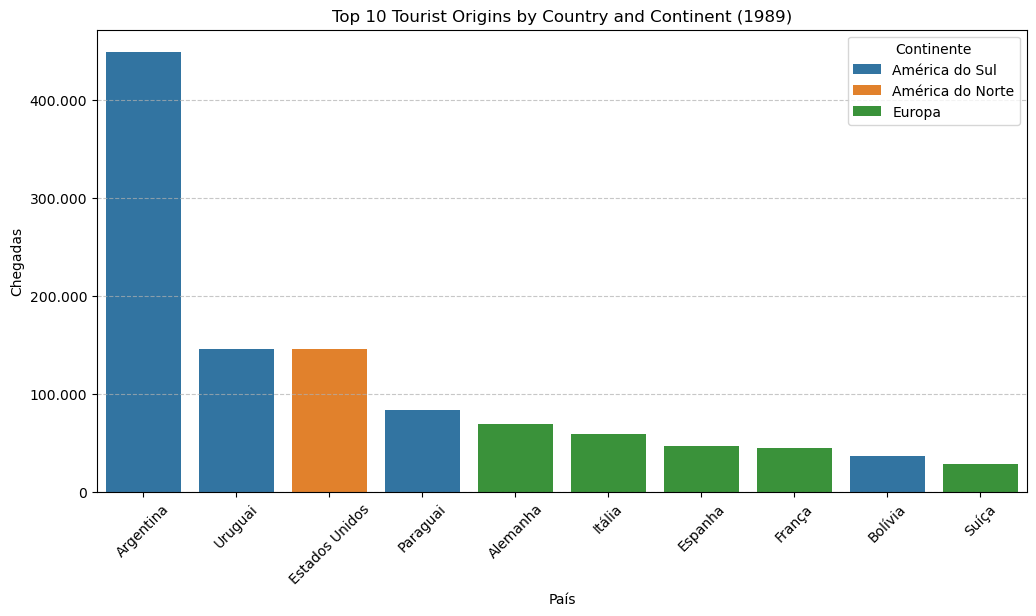

In [25]:
# Refined visualization: Using a bar chart with 'hue' to categorize by Continent. 
# This approach highlights regional dominance and clarifies the top 10 ranking after diluding other countries by continent.

plt.figure(figsize=(12, 6))
sns.barplot(data=country_totals.head(10), x='País', y='Chegadas', hue='Continente')

plt.title('Top 10 Tourist Origins by Country and Continent (1989)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.'))
)
plt.show()

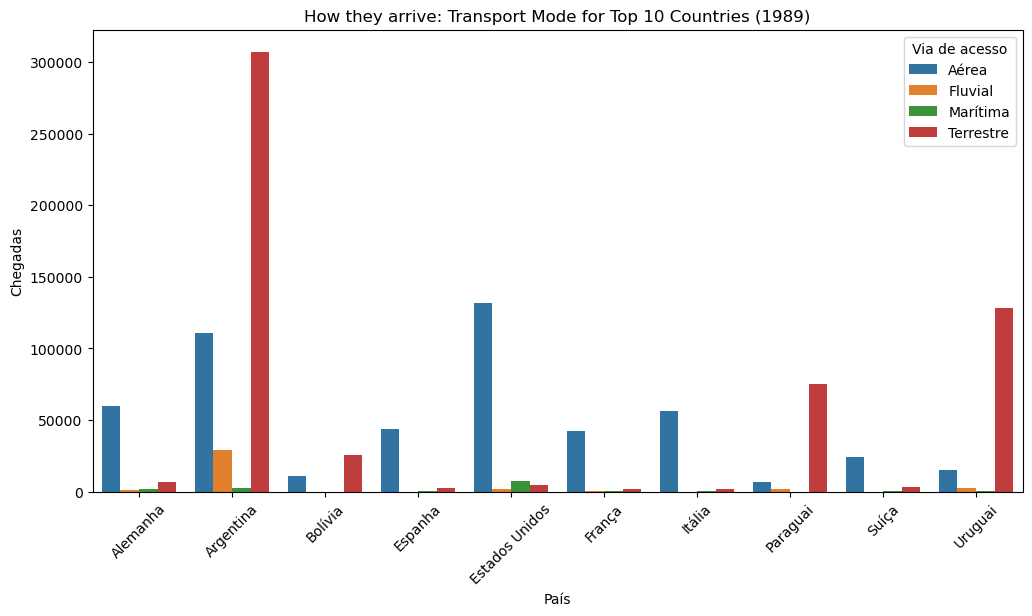

In [26]:
# Grouping Top 10 countries by Transport Type
top_10_names = country_totals.head(10)['País']
transport_analysis = travels_df[travels_df['País'].isin(top_10_names)]

# Aggregating to see the transport preference
transport_totals = transport_analysis.groupby(['País', 'Via de acesso'])['Chegadas'].sum().reset_index()

# Visualizing Transport Mode for the Top 10
plt.figure(figsize=(12, 6))
sns.barplot(data=transport_totals, x='País', y='Chegadas', hue='Via de acesso')
plt.title('How they arrive: Transport Mode for Top 10 Countries (1989)')
plt.xticks(rotation=45)
plt.show()

As expected in here, most countries that borders with Brazil comes from 'Terrestre' kind of transport, while countries from 
north america and europe have 'Aérea' dominance

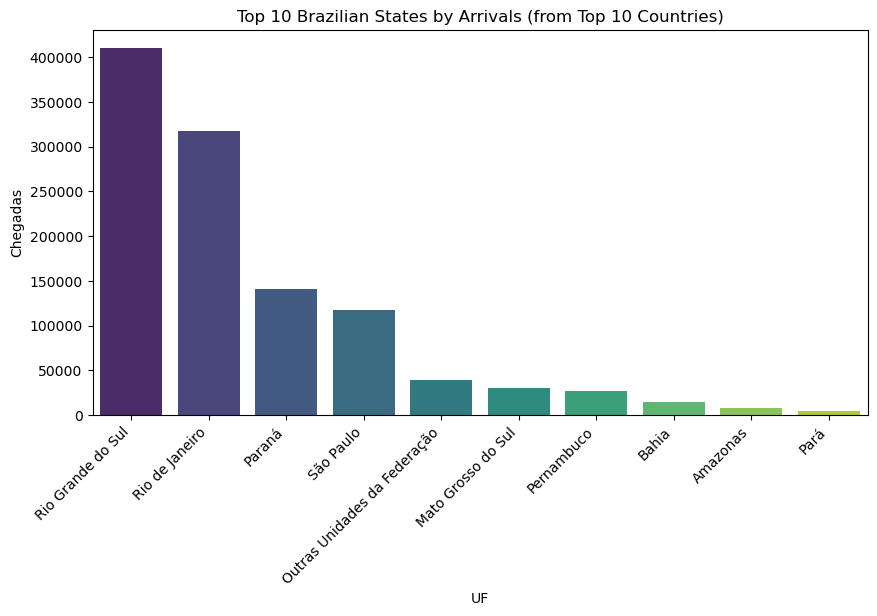

In [27]:
# Analyzing the main Gateways (States) for these tourists
state_destinations = transport_analysis.groupby('UF')['Chegadas'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=state_destinations, x='UF', y='Chegadas', hue='UF', palette='viridis', legend=False)
plt.title('Top 10 Brazilian States by Arrivals (from Top 10 Countries)')
plt.xticks(rotation=45, ha='right')
plt.show()

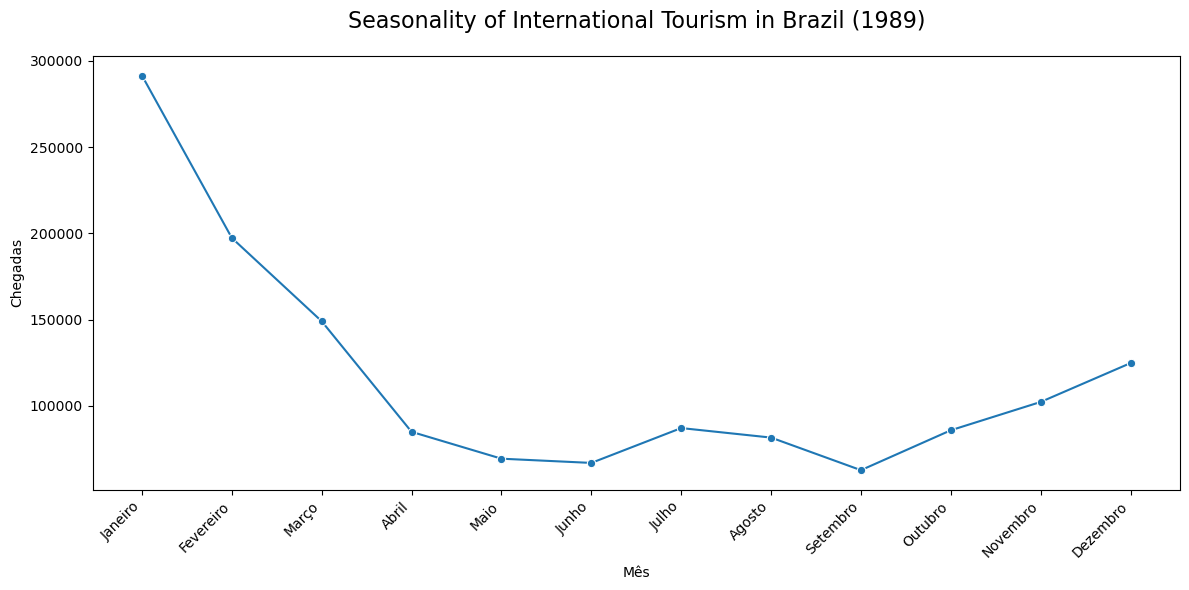

In [28]:
# And last, an analysis in lineplot, it helps to visualize which months tourists prefer to travel to Brazil.
monthly_data = travels_df.groupby('Mês')['Chegadas'].sum().reset_index()

monthly_data['Mês'] = monthly_data['Mês'].str.capitalize()

meses_ordem = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 
               'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']

monthly_data['Mês'] = pd.Categorical(monthly_data['Mês'], categories=meses_ordem, ordered=True)
monthly_data = monthly_data.sort_values('Mês')

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_data, x='Mês', y='Chegadas', marker='o', linewidth=1.5)

plt.title('Seasonality of International Tourism in Brazil (1989)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Conclusions:

### What I learned (Notebook):
It was fun analyzing all this data. I was able to identify some sorts of problems I will have to deal with in the future, like old formats with different encodings, missing data like 'Fluvial' for 'Mato Grosso do Sul', and also was able to explore a more dynamic approach. Executing cell by cell, I was able to easily test different formats of graphs, identifying which was best for each case.

### Descriptive analysis:
From the data gathered, I was able to come to a conclusion that in 1989 traveling wasn't as easy as it is today. In Brazil, the ranking was mostly occupied by border countries, and it was very common to travel by land. It also showcased that the South was the region that received the most tourists; sadly we can't tell by this data if they stayed in that region or started travelling further to reach other areas. The high season, spanning from December to March, shows the strongest results, with January and February reaching the absolute peak of arrivals. As expected, the Brazilian summer is when the country attracts the most international interest.

### Predictive analysis:
It was very interesting to see how different the scenario was (or at least I expect it to be) from the past compared to the present. When I analyze the full data, I expect to see a lot more visitors in the Southeast than in the South. It was also very interesting to see it was mainly due to borderline countries; I expect that they keep a high value. It will be very interesting to see if Argentina keeps being the top source of tourists in Brazil, or if it changed along the years. Also, regarding the way they travel, it's expect to see a very big growth in flights compared to any other travel modes. But one thing I don't expect to change is a peak in the summer season in Brazil, but will be interesting seeing how much they increase on other seasons.